# Projeto: Análise do comportamento dos clientes em corridas por aplicativo
#

Neste trabalho será feita uma análise dos dados de corridas por aplicativo com foco
no comportamento dos clientes. A proposta é passar pelas etapas de coleta, limpeza,
organização e análise exploratória dos dados, para entender melhor como o serviço é usado.
#
Serão observados pontos como:
- horários de maior uso;
- dias com mais corridas;
- tipos de veículo mais solicitados;
- forma de pagamento;
- valor e distância das corridas;
- relação entre tempo de atendimento e status da corrida.
#
Ao final, também serão indicadas possíveis aplicações em Inteligência Artificial,
a partir dos padrões encontrados nos dados.

In [67]:
# importar bibliotecas
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ocultar warnings
warnings.filterwarnings("ignore")

# configurar gráficos
sns.set_theme(style="whitegrid")

# criar pasta para salvar imagens
os.makedirs("graficos", exist_ok=True)

## 1. Coleta dos dados
#
Nesta etapa o dataset será carregado para o ambiente de análise.
Depois disso, será feita uma verificação inicial para entender o tamanho da base.

In [68]:
# carregar dataset
df = pd.read_csv("/kaggle/input/datasets/yashdevladdha/uber-ride-analytics-dashboard/ncr_ride_bookings.csv")

# exibir dimensão
print("## 1. Coleta dos dados")
print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")
print("-" * 60)

## 1. Coleta dos dados
Dimensões do dataset: 150000 linhas e 21 colunas
------------------------------------------------------------


## 2. Visualização inicial
#
Aqui serão mostradas as primeiras linhas do dataset para ter uma visão geral
dos dados disponíveis.

In [69]:
# mostrar primeiras linhas
print("## 2. Visualização inicial")
print(df.head())
print("-" * 60)

## 2. Visualização inicial
         Date      Time    Booking ID   Booking Status   Customer ID  \
0  2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1  2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2  2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3  2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4  2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   

    Vehicle Type      Pickup Location      Drop Location  Avg VTAT  Avg CTAT  \
0          eBike          Palam Vihar            Jhilmil       NaN       NaN   
1       Go Sedan        Shastri Nagar  Gurgaon Sector 56       4.9      14.0   
2           Auto              Khandsa      Malviya Nagar      13.4      25.8   
3  Premier Sedan  Central Secretariat           Inderlok      13.1      28.5   
4           Bike     Ghitorni Village        Khan Market       5.3      19.6   

   ...  Reason for cancelling by Customer Cancelled Rides b

## 3. Informações gerais da base
#
Nesta parte será analisada a estrutura do dataset:
- nome das colunas;
- tipos de dados;
- quantidade de valores preenchidos.

In [70]:
# exibir informações gerais
print("## 3. Informações gerais")
df.info()
print("-" * 60)

## 3. Informações gerais
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for can

## 4. Descrição de campos principais
#
Abaixo estão algumas colunas importantes da base e o que elas representam.

In [71]:
# dicionário simples de descrição
descricao_campos = {
    "Booking ID": "Identificador da corrida.",
    "Date": "Data da solicitação da corrida.",
    "Time": "Horário da solicitação da corrida.",
    "Booking Status": "Situação final da corrida.",
    "Customer ID": "Identificador do cliente.",
    "Vehicle Type": "Tipo de veículo solicitado.",
    "Pickup Location": "Local de embarque.",
    "Drop Location": "Local de destino.",
    "Avg VTAT": "Tempo médio relacionado ao veículo.",
    "Avg CTAT": "Tempo médio relacionado ao atendimento ao cliente.",
    "Booking Value": "Valor da corrida.",
    "Ride Distance": "Distância da viagem.",
    "Driver Ratings": "Avaliação do motorista.",
    "Customer Rating": "Avaliação do cliente.",
    "Payment Method": "Forma de pagamento utilizada."
}

print("## 4. Descrição de campos")
for campo, descricao in descricao_campos.items():
    print(f"{campo}: {descricao}")
print("-" * 60)

## 4. Descrição de campos
Booking ID: Identificador da corrida.
Date: Data da solicitação da corrida.
Time: Horário da solicitação da corrida.
Booking Status: Situação final da corrida.
Customer ID: Identificador do cliente.
Vehicle Type: Tipo de veículo solicitado.
Pickup Location: Local de embarque.
Drop Location: Local de destino.
Avg VTAT: Tempo médio relacionado ao veículo.
Avg CTAT: Tempo médio relacionado ao atendimento ao cliente.
Booking Value: Valor da corrida.
Ride Distance: Distância da viagem.
Driver Ratings: Avaliação do motorista.
Customer Rating: Avaliação do cliente.
Payment Method: Forma de pagamento utilizada.
------------------------------------------------------------


## 5. Limpeza dos dados
#
Nesta etapa serão feitas algumas ações básicas de limpeza:
- remoção de linhas duplicadas;
- análise de valores ausentes;
- tratamento de valores faltantes em colunas importantes.
#
Para as análises gerais, a base será mantida o mais completa possível.
Já nas análises financeiras, será criada uma base separada apenas com valores válidos
de corrida.

In [72]:
# remover duplicatas
df.drop_duplicates(inplace=True)

print("## 5. Limpeza dos dados")
print(f"Quantidade de linhas após remover duplicatas: {len(df)}")
print("-" * 60)

## 5. Limpeza dos dados
Quantidade de linhas após remover duplicatas: 150000
------------------------------------------------------------


### 5.1 Valores ausentes
#
Agora será verificado quais colunas possuem valores ausentes e em que quantidade.

In [73]:
# calcular valores ausentes
nan_total = df.isnull().sum()
nan_percent = (nan_total / len(df) * 100).round(2)

nan_table = pd.DataFrame({
    "Total NaNs": nan_total,
    "Percentual (%)": nan_percent
})

# filtrar apenas colunas com NaN
nan_table = nan_table[nan_table["Total NaNs"] > 0].sort_values(by="Total NaNs", ascending=False)

print("## 5.1 Valores ausentes")
print(nan_table)
print("-" * 60)

## 5.1 Valores ausentes
                                   Total NaNs  Percentual (%)
Incomplete Rides                       141000            94.0
Incomplete Rides Reason                141000            94.0
Cancelled Rides by Customer            139500            93.0
Reason for cancelling by Customer      139500            93.0
Cancelled Rides by Driver              123000            82.0
Driver Cancellation Reason             123000            82.0
Driver Ratings                          57000            38.0
Customer Rating                         57000            38.0
Avg CTAT                                48000            32.0
Ride Distance                           48000            32.0
Booking Value                           48000            32.0
Payment Method                          48000            32.0
Avg VTAT                                10500             7.0
------------------------------------------------------------


### 5.2 Tratamento dos valores ausentes
#
Algumas colunas numéricas importantes serão preenchidas com a mediana
para manter a maior quantidade possível de registros na base.
#
A variável `Booking Value` não será preenchida neste momento, porque ela será tratada
separadamente nas análises em que o valor da corrida for realmente necessário.

In [74]:
# preencher colunas numéricas com mediana
colunas_numericas_mediana = [
    "Avg VTAT",
    "Avg CTAT",
    "Ride Distance",
    "Driver Ratings",
    "Customer Rating"
]

for col in colunas_numericas_mediana:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("## 5.2 Tratamento concluído")
print(df[colunas_numericas_mediana].isnull().sum())
print("-" * 60)

## 5.2 Tratamento concluído
Avg VTAT           0
Avg CTAT           0
Ride Distance      0
Driver Ratings     0
Customer Rating    0
dtype: int64
------------------------------------------------------------


### 5.3 Base específica para análises de valor
#
Para as análises relacionadas ao valor da corrida, serão considerados apenas registros
com `Booking Value` positivo e não nulo.
#
Isso evita distorções causadas por corridas sem valor registrado ou valores negativos.

In [75]:
# criar base apenas com valores válidos de corrida
df_valor = df[
    (df["Booking Value"].notna()) &
    (df["Booking Value"] > 0)
].copy()

print("## 5.3 Base para análises de valor")
print(f"Quantidade de linhas em df_valor: {len(df_valor)}")
print("-" * 60)

## 5.3 Base para análises de valor
Quantidade de linhas em df_valor: 102000
------------------------------------------------------------


## 6. Organização dos dados
#
Nesta etapa os dados serão organizados para facilitar a análise.
Serão criadas novas variáveis a partir da data e do horário da corrida.

In [76]:
# criar coluna datetime
df["DateTime"] = pd.to_datetime(df["Date"] + " " + df["Time"], errors="coerce")
df_valor["DateTime"] = pd.to_datetime(df_valor["Date"] + " " + df_valor["Time"], errors="coerce")

# criar novas colunas de tempo
for base in [df, df_valor]:
    base["Dia_da_Semana"] = base["DateTime"].dt.day_name()
    base["Hora_do_Dia"] = base["DateTime"].dt.hour
    base["Dia_da_Semana_Num"] = base["DateTime"].dt.dayofweek
    base["Mes"] = base["DateTime"].dt.month

print("## 6. Organização dos dados")
print(df[["Date", "Time", "DateTime", "Dia_da_Semana", "Hora_do_Dia", "Mes"]].head())
print("-" * 60)

## 6. Organização dos dados
         Date      Time            DateTime Dia_da_Semana  Hora_do_Dia  Mes
0  2024-03-23  12:29:38 2024-03-23 12:29:38      Saturday           12    3
1  2024-11-29  18:01:39 2024-11-29 18:01:39        Friday           18   11
2  2024-08-23  08:56:10 2024-08-23 08:56:10        Friday            8    8
3  2024-10-21  17:17:25 2024-10-21 17:17:25        Monday           17   10
4  2024-09-16  22:08:00 2024-09-16 22:08:00        Monday           22    9
------------------------------------------------------------


### 6.1 Criação de variáveis auxiliares
#
Também serão criadas algumas variáveis derivadas para ajudar na análise:
- `Cancelamento`: indica se a corrida foi concluída ou não;
- `Valor_por_km`: ajuda a entender o custo em relação à distância;
- `Horario_Pico`: indica se a corrida ocorreu em horário de pico.

In [77]:
# criar variável de cancelamento
df["Cancelamento"] = np.where(df["Booking Status"] == "Completed", 0, 1)
df_valor["Cancelamento"] = np.where(df_valor["Booking Status"] == "Completed", 0, 1)

# criar valor por km na base com valores válidos
df_valor["Valor_por_km"] = df_valor["Booking Value"] / df_valor["Ride Distance"]
df_valor["Valor_por_km"] = df_valor["Valor_por_km"].replace([np.inf, -np.inf], np.nan)
df_valor["Valor_por_km"] = df_valor["Valor_por_km"].fillna(df_valor["Valor_por_km"].median())

# criar indicador de horário de pico
df["Horario_Pico"] = np.where(
    (df["Hora_do_Dia"].between(7, 9)) | (df["Hora_do_Dia"].between(17, 20)),
    1,
    0
)

df_valor["Horario_Pico"] = np.where(
    (df_valor["Hora_do_Dia"].between(7, 9)) | (df_valor["Hora_do_Dia"].between(17, 20)),
    1,
    0
)

print("## 6.1 Variáveis auxiliares criadas")
print(df[["Cancelamento", "Horario_Pico"]].head())
print(df_valor[["Booking Value", "Valor_por_km"]].head())
print("-" * 60)

## 6.1 Variáveis auxiliares criadas
   Cancelamento  Horario_Pico
0             1             0
1             1             1
2             0             1
3             0             1
4             0             0
   Booking Value  Valor_por_km
1          237.0     41.361257
2          627.0     46.170839
3          416.0     12.228101
4          737.0     15.287285
5          316.0     65.154639
------------------------------------------------------------


## 7. AED - análise exploratória dos dados
#
A partir daqui serão feitas análises para entender melhor as características da base
e identificar padrões relacionados ao uso do serviço de transporte por aplicativo.

### 7.1 Variáveis categóricas
#
Primeiro serão observadas algumas colunas categóricas importantes:
- status da corrida;
- tipo de veículo;
- forma de pagamento;
- local de embarque.

In [78]:
# definir colunas categóricas
CATEGORICAL_COLS = ["Booking Status", "Vehicle Type", "Payment Method", "Pickup Location"]

print("## 7.1 Variáveis categóricas")

for col in CATEGORICAL_COLS:
    print(f"\n--- Coluna: {col} ---")
    counts = df[col].value_counts(dropna=False).head(10)

    if df[col].nunique() > 50:
        print(f"Esta coluna tem {df[col].nunique()} valores únicos. Mostrando Top 10:")

    print(counts)

print("-" * 60)

## 7.1 Variáveis categóricas

--- Coluna: Booking Status ---
Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

--- Coluna: Vehicle Type ---
Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

--- Coluna: Payment Method ---
Payment Method
NaN            48000
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64

--- Coluna: Pickup Location ---
Esta coluna tem 176 valores únicos. Mostrando Top 10:
Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21   

### 7.2 Gráficos das variáveis categóricas
#
Agora serão gerados alguns gráficos para visualizar a distribuição dessas categorias.

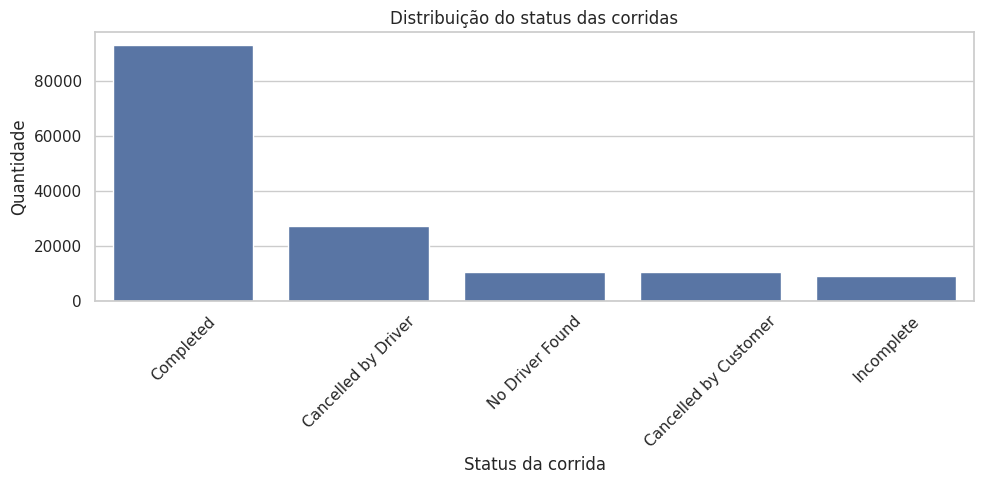

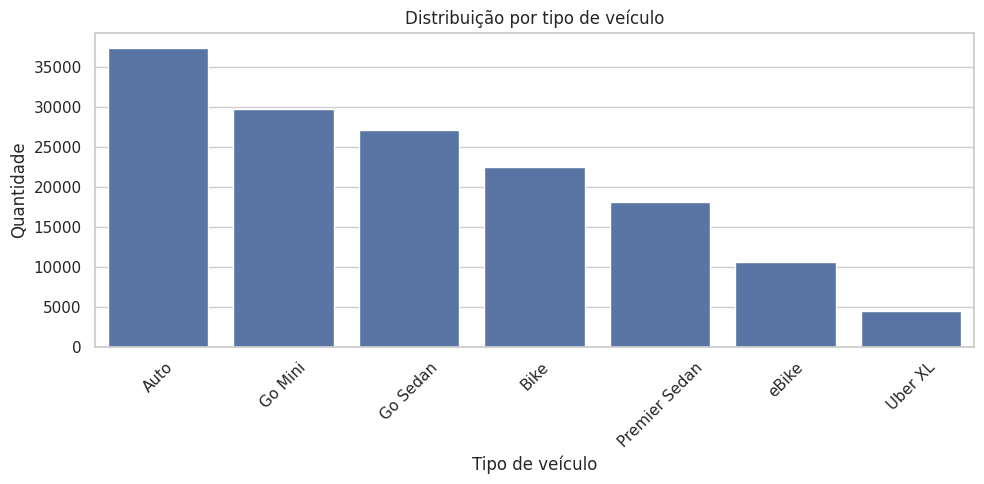

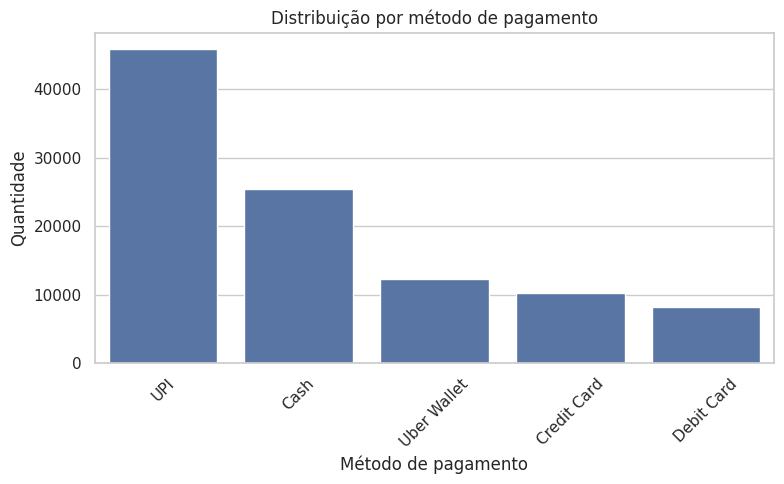

In [79]:
# gráfico de status das corridas
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Booking Status", order=df["Booking Status"].value_counts().index)
plt.title("Distribuição do status das corridas")
plt.xlabel("Status da corrida")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("graficos/status_corridas.png", bbox_inches="tight")
plt.show()

# gráfico de tipo de veículo
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Vehicle Type", order=df["Vehicle Type"].value_counts().index)
plt.title("Distribuição por tipo de veículo")
plt.xlabel("Tipo de veículo")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("graficos/tipo_veiculo.png", bbox_inches="tight")
plt.show()

# gráfico de método de pagamento
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Payment Method", order=df["Payment Method"].value_counts().index)
plt.title("Distribuição por método de pagamento")
plt.xlabel("Método de pagamento")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("graficos/metodo_pagamento.png", bbox_inches="tight")
plt.show()

### 7.3 Variáveis numéricas gerais
#
Nesta etapa serão observadas variáveis numéricas ligadas ao uso do serviço,
como tempos médios, distância e avaliações.

In [80]:
# definir colunas numéricas gerais
NUMERIC_FEATURES_GERAIS = [
    "Avg VTAT",
    "Avg CTAT",
    "Ride Distance",
    "Driver Ratings",
    "Customer Rating"
]

print("## 7.3 Estatísticas descritivas gerais")
print(df[NUMERIC_FEATURES_GERAIS].describe())
print("-" * 60)

## 7.3 Estatísticas descritivas gerais
            Avg VTAT       Avg CTAT  Ride Distance  Driver Ratings  \
count  150000.000000  150000.000000  150000.000000   150000.000000   
mean        8.445407      29.037753      24.343568        4.257215   
std         3.639311       7.343053      11.554362        0.345619   
min         2.000000      10.000000       1.000000        3.000000   
25%         5.600000      25.000000      17.360000        4.200000   
50%         8.300000      28.800000      23.720000        4.300000   
75%        11.000000      32.900000      30.650000        4.300000   
max        20.000000      45.000000      50.000000        5.000000   

       Customer Rating  
count    150000.000000  
mean          4.440842  
std           0.347835  
min           3.000000  
25%           4.300000  
50%           4.500000  
75%           4.600000  
max           5.000000  
------------------------------------------------------------


### 7.4 Variáveis numéricas relacionadas ao valor
#
Para as análises financeiras, será usada a base `df_valor`,
que contém apenas corridas com valor positivo e não nulo.

In [81]:
# definir colunas numéricas de valor
NUMERIC_FEATURES_VALOR = [
    "Booking Value",
    "Ride Distance",
    "Avg VTAT",
    "Avg CTAT",
    "Driver Ratings",
    "Customer Rating",
    "Valor_por_km"
]

print("## 7.4 Estatísticas descritivas de valor")
print(df_valor[NUMERIC_FEATURES_VALOR].describe())
print("-" * 60)

## 7.4 Estatísticas descritivas de valor
       Booking Value  Ride Distance       Avg VTAT       Avg CTAT  \
count  102000.000000  102000.000000  102000.000000  102000.000000   
mean      508.295912      24.637012       8.291455      29.149636   
std       395.805774      14.002138       3.712160       8.902577   
min        50.000000       1.000000       2.000000      10.000000   
25%       234.000000      12.460000       5.100000      21.600000   
50%       414.000000      23.720000       8.200000      28.800000   
75%       689.000000      36.820000      11.400000      36.800000   
max      4277.000000      50.000000      15.000000      45.000000   

       Driver Ratings  Customer Rating   Valor_por_km  
count   102000.000000    102000.000000  102000.000000  
mean         4.237081         4.413003      37.876936  
std          0.417611         0.418932      64.155727  
min          3.000000         3.000000       1.008065  
25%          4.100000         4.200000       9.488777  
5

### 7.5 Distribuição das variáveis numéricas gerais
#
Aqui serão gerados histogramas para observar a distribuição das variáveis
da base geral.

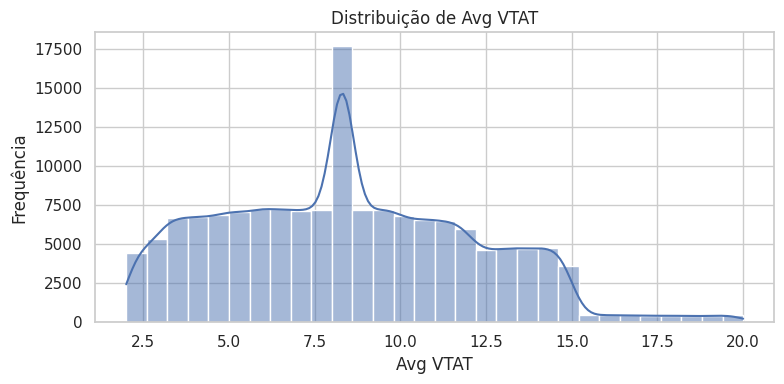

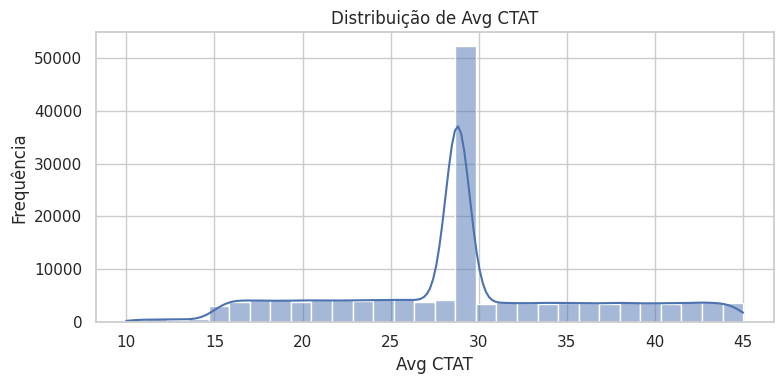

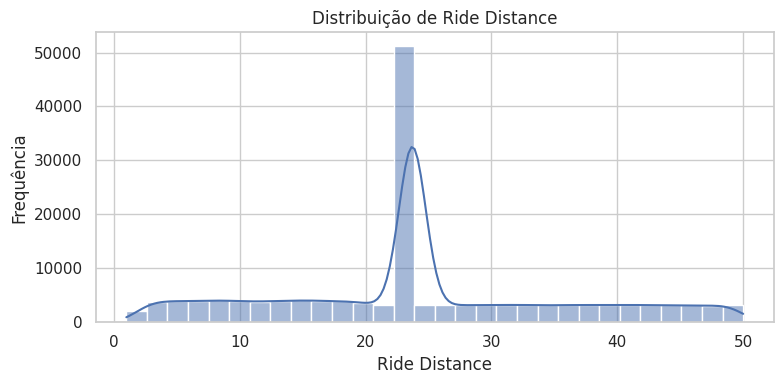

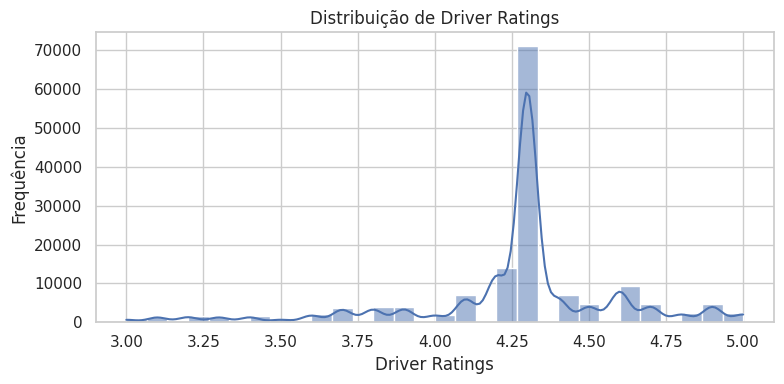

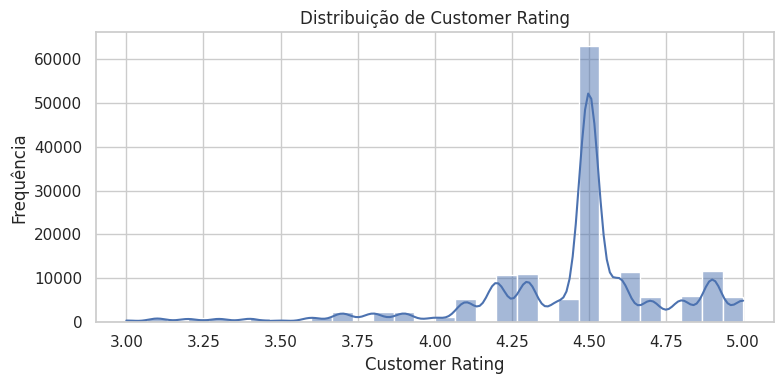

In [82]:
# gerar histogramas gerais
for col in NUMERIC_FEATURES_GERAIS:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.tight_layout()
    nome_arquivo = col.lower().replace(" ", "_")
    plt.savefig(f"graficos/hist_{nome_arquivo}.png", bbox_inches="tight")
    plt.show()

### 7.6 Distribuição das variáveis relacionadas ao valor
#
Nesta etapa serão gerados histogramas para as variáveis financeiras da base `df_valor`.

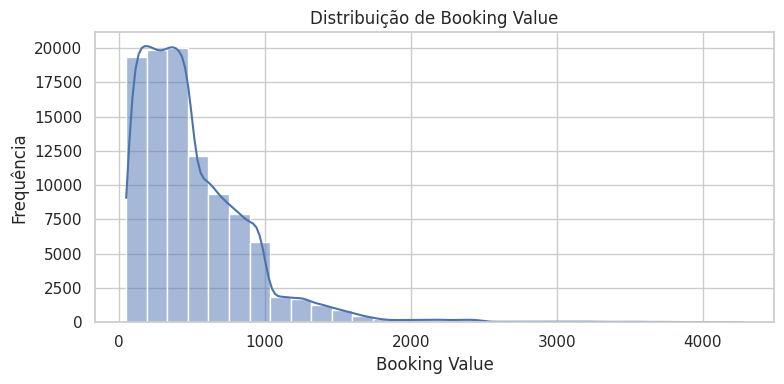

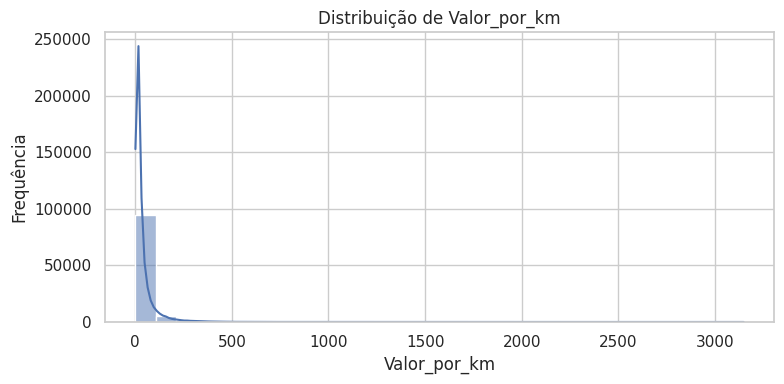

In [83]:
# gerar histogramas de valor
for col in ["Booking Value", "Valor_por_km"]:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_valor[col], bins=30, kde=True)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.tight_layout()
    nome_arquivo = col.lower().replace(" ", "_")
    plt.savefig(f"graficos/hist_{nome_arquivo}.png", bbox_inches="tight")
    plt.show()

### 7.7 Correlação entre variáveis numéricas
#
A matriz de correlação ajuda a verificar se existe relação entre variáveis
como valor da corrida, distância, tempos médios e avaliações.
#
Nesta parte será usada a base `df_valor`, pois ela contém apenas valores válidos
de corrida.

## 7.7 Matriz de correlação
                 Booking Value  Ride Distance  Avg VTAT  Avg CTAT  \
Booking Value           1.0000         0.0052    0.0023    0.0002   
Ride Distance           0.0052         1.0000    0.0630    0.1015   
Avg VTAT                0.0023         0.0630    1.0000    0.0622   
Avg CTAT                0.0002         0.1015    0.0622    1.0000   
Driver Ratings         -0.0002        -0.0164   -0.0142   -0.0142   
Customer Rating        -0.0002        -0.0160   -0.0161   -0.0197   
Valor_por_km            0.4555        -0.4730   -0.0388   -0.0629   

                 Driver Ratings  Customer Rating  Valor_por_km  
Booking Value           -0.0002          -0.0002        0.4555  
Ride Distance           -0.0164          -0.0160       -0.4730  
Avg VTAT                -0.0142          -0.0161       -0.0388  
Avg CTAT                -0.0142          -0.0197       -0.0629  
Driver Ratings           1.0000           0.0020        0.0092  
Customer Rating          0.00

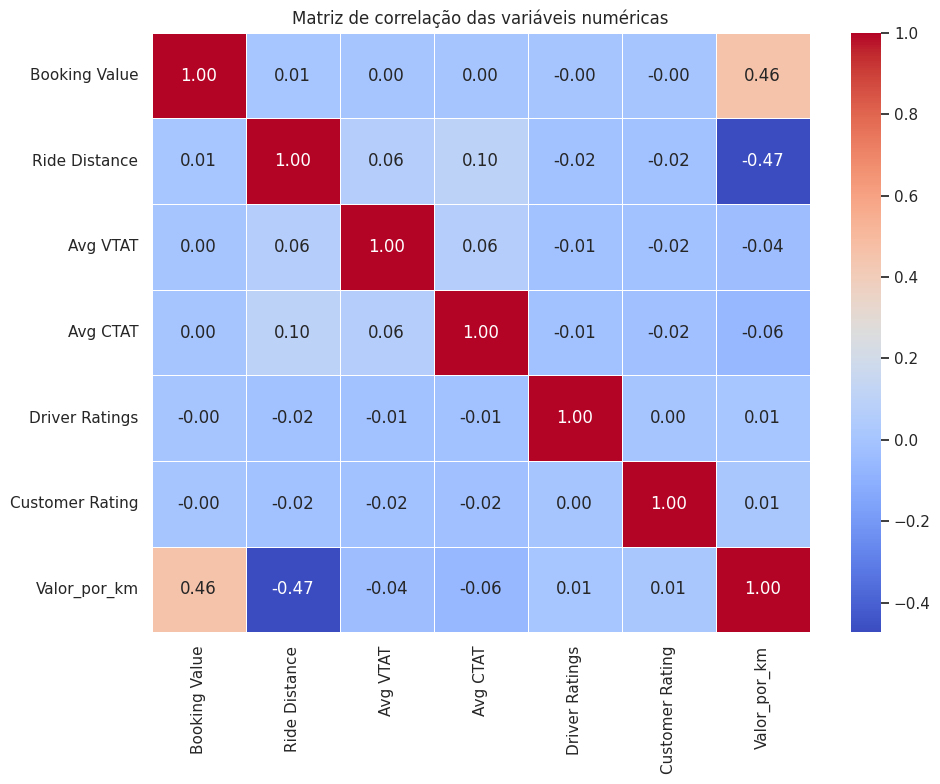

In [84]:
# criar base para correlação financeira
df_corr = df_valor[NUMERIC_FEATURES_VALOR].copy()

# calcular correlação
correlation_matrix = df_corr.corr()

print("## 7.7 Matriz de correlação")
print(correlation_matrix.round(4))
print("-" * 60)

# plotar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True
)
plt.title("Matriz de correlação das variáveis numéricas")
plt.tight_layout()
plt.savefig("graficos/heatmap_correlacao.png", bbox_inches="tight")
plt.show()

### 7.8 Padrão de uso por hora do dia
#
Nesta parte será analisada a quantidade de corridas em cada hora do dia,
para identificar períodos de maior uso do serviço.

## 7.8 Corridas por hora do dia
Hora_do_Dia
0      1373
1      1360
2      1339
3      1383
4      1321
5      2786
6      4160
7      5450
8      6861
9      8234
10     9577
11     8390
12     7006
13     5470
14     7031
15     8202
16     9633
17    11044
18    12397
19    11047
20     9630
21     8103
22     5441
23     2762
Name: Booking ID, dtype: int64
------------------------------------------------------------


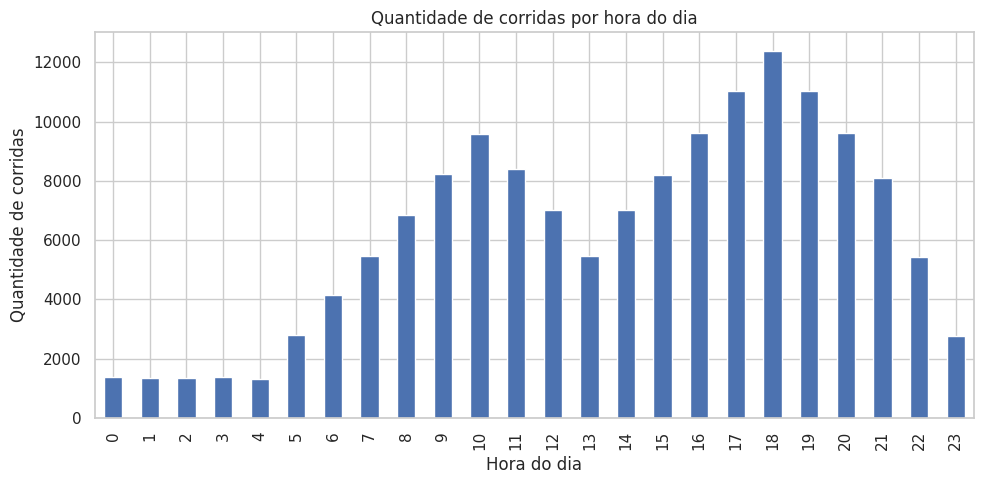

In [85]:
# agrupar por hora
demanda_hora = df.groupby("Hora_do_Dia")["Booking ID"].count().sort_index()

print("## 7.8 Corridas por hora do dia")
print(demanda_hora)
print("-" * 60)

# gráfico por hora
plt.figure(figsize=(10, 5))
demanda_hora.plot(kind="bar")
plt.title("Quantidade de corridas por hora do dia")
plt.xlabel("Hora do dia")
plt.ylabel("Quantidade de corridas")
plt.tight_layout()
plt.savefig("graficos/demanda_por_hora.png", bbox_inches="tight")
plt.show()

### 7.9 Padrão de uso por dia da semana
#
Aqui será observada a distribuição das corridas ao longo da semana.

## 7.9 Corridas por dia da semana
Dia_da_Semana
Monday       21644
Tuesday      21391
Wednesday    21413
Thursday     21215
Friday       21397
Saturday     21542
Sunday       21398
Name: Booking ID, dtype: int64
------------------------------------------------------------


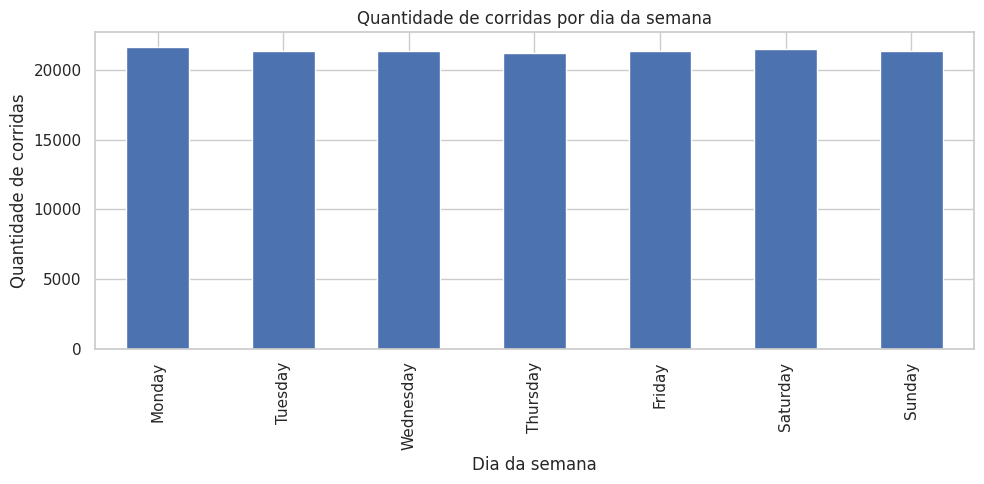

In [86]:
# definir ordem dos dias
dias_ordem = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# agrupar por dia da semana
demanda_dia = df.groupby("Dia_da_Semana")["Booking ID"].count().reindex(dias_ordem)

print("## 7.9 Corridas por dia da semana")
print(demanda_dia)
print("-" * 60)

# gráfico por dia da semana
plt.figure(figsize=(10, 5))
demanda_dia.plot(kind="bar")
plt.title("Quantidade de corridas por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Quantidade de corridas")
plt.tight_layout()
plt.savefig("graficos/demanda_por_dia.png", bbox_inches="tight")
plt.show()

### 7.10 Relação entre tempo médio e status da corrida
#
Agora será analisado como o tempo médio de atendimento ao cliente varia
conforme o status final da corrida.

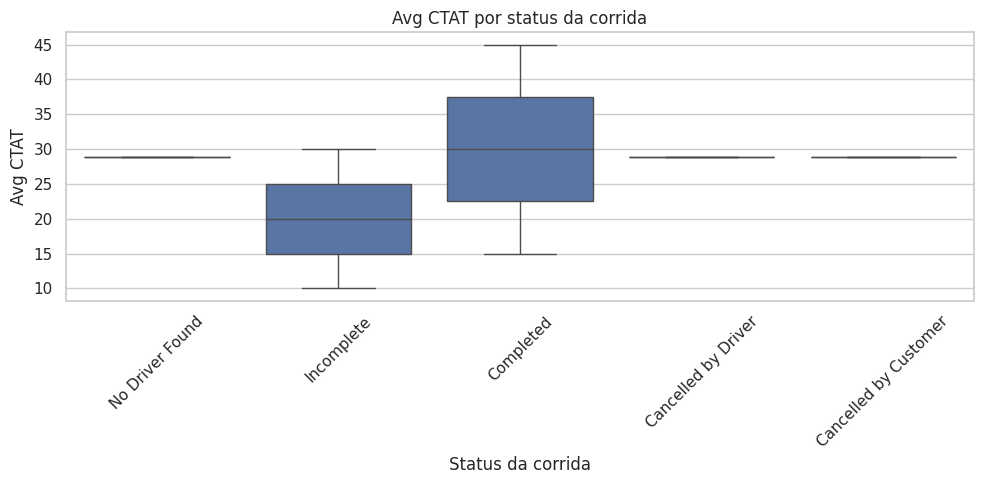

In [87]:
# boxplot de avg ctat por status
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Booking Status", y="Avg CTAT")
plt.title("Avg CTAT por status da corrida")
plt.xlabel("Status da corrida")
plt.ylabel("Avg CTAT")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("graficos/ctat_por_status.png", bbox_inches="tight")
plt.show()

### 7.11 Relação entre cancelamento e horário de pico
#
Nesta análise será observado se há diferença entre corridas concluídas
e não concluídas nos horários de pico.

## 7.11 Cancelamento por horário de pico
Cancelamento      0      1
Horario_Pico              
0             53023  32314
1             39977  24686
------------------------------------------------------------


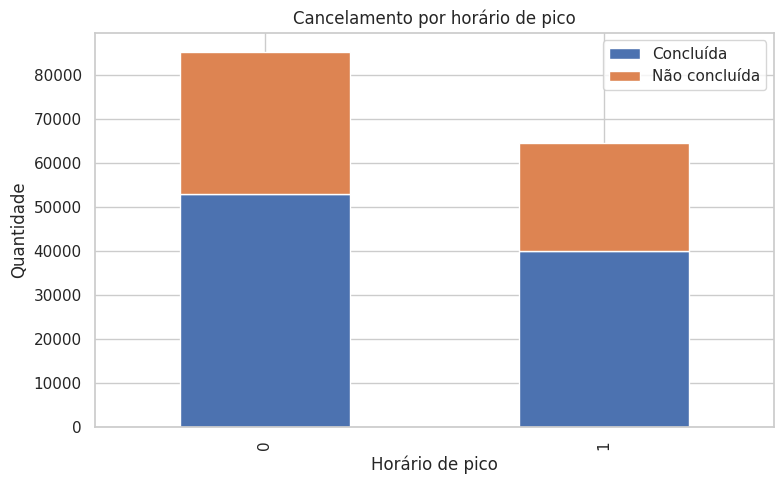

In [88]:
# tabela simples de cancelamento por horário de pico
cancelamento_pico = pd.crosstab(df["Horario_Pico"], df["Cancelamento"])

print("## 7.11 Cancelamento por horário de pico")
print(cancelamento_pico)
print("-" * 60)

# gráfico
cancelamento_pico.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Cancelamento por horário de pico")
plt.xlabel("Horário de pico")
plt.ylabel("Quantidade")
plt.legend(["Concluída", "Não concluída"])
plt.tight_layout()
plt.savefig("graficos/cancelamento_horario_pico.png", bbox_inches="tight")
plt.show()

### 7.12 Análise de anomalias no valor da corrida
#
Nesta etapa será usado o método do IQR para identificar corridas com valores
muito fora do padrão.
#
A análise será feita com a base `df_valor`, pois ela contém apenas corridas
com valor positivo e válido.

## 7.12 Análise de anomalias
Q1: 234.00
Q3: 689.00
IQR: 455.00
Limite inferior: -448.50
Limite superior: 1371.50
Total de anomalias: 3435
------------------------------------------------------------


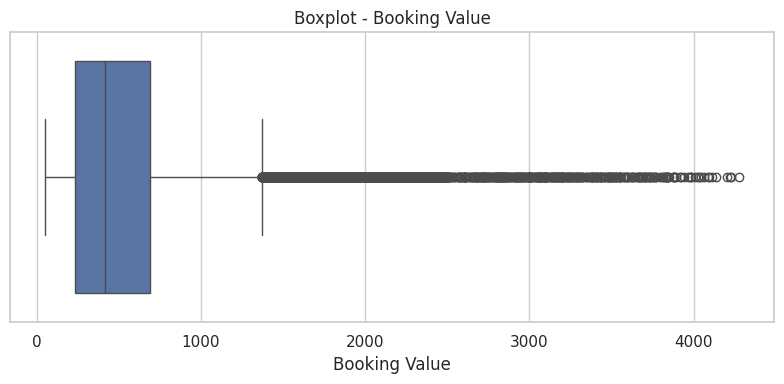

In [89]:
# escolher coluna
coluna_analise = "Booking Value"

# usar base de valor
df_limpo = df_valor.copy()

# calcular quartis
Q1 = df_limpo[coluna_analise].quantile(0.25)
Q3 = df_limpo[coluna_analise].quantile(0.75)
IQR = Q3 - Q1

# calcular limites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# identificar anomalias
anomalias = df_limpo[
    (df_limpo[coluna_analise] < limite_inferior) |
    (df_limpo[coluna_analise] > limite_superior)
]

print("## 7.12 Análise de anomalias")
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")
print(f"Total de anomalias: {len(anomalias)}")
print("-" * 60)

# boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_limpo[coluna_analise])
plt.title("Boxplot - Booking Value")
plt.tight_layout()
plt.savefig("graficos/boxplot_booking_value.png", bbox_inches="tight")
plt.show()

## 8. Possíveis aplicações em Inteligência Artificial
#
A partir das análises feitas, os dados podem ser usados em aplicações como:
- previsão de cancelamento de corridas;
- previsão de demanda por horário ou dia;
- estimativa do valor da corrida;
- detecção de corridas fora do padrão;
- segmentação de perfis de uso dos clientes.

In [90]:
print("## 8. Possíveis aplicações em IA")
print("- Previsão de cancelamento")
print("- Previsão de demanda")
print("- Estimativa de valor da corrida")
print("- Detecção de anomalias")
print("- Segmentação de perfis de clientes")
print("-" * 60)

## 8. Possíveis aplicações em IA
- Previsão de cancelamento
- Previsão de demanda
- Estimativa de valor da corrida
- Detecção de anomalias
- Segmentação de perfis de clientes
------------------------------------------------------------


## 9. Conclusão
#
Com a coleta, limpeza, organização e análise exploratória dos dados, foi possível
entender melhor algumas características do uso do serviço de transporte por aplicativo.
#
A análise mostrou padrões de horários e dias com maior movimento, diferenças entre
tipos de veículo e formas de pagamento, além da relação entre variáveis como distância,
valor da corrida e tempos médios de atendimento.
#
Também foi possível identificar corridas com valores fora do padrão e levantar
possibilidades de uso desses dados em modelos de Inteligência Artificial.

In [91]:
# mensagem final
print("Projeto executado com sucesso.")
print("Etapas realizadas: coleta, limpeza, organização e AED.")
print("Os gráficos foram salvos na pasta 'graficos'.")

Projeto executado com sucesso.
Etapas realizadas: coleta, limpeza, organização e AED.
Os gráficos foram salvos na pasta 'graficos'.
